<h2 align='center'>ML Flow on Dummy data</h2>

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [44]:
print(make_classification.__doc__)

Generate a random n-class classification problem.

    This initially creates clusters of points normally distributed (std=1)
    about vertices of an ``n_informative``-dimensional hypercube with sides of
    length ``2*class_sep`` and assigns an equal number of clusters to each
    class. It introduces interdependence between these features and adds
    various types of further noise to the data.

    Without shuffling, ``X`` horizontally stacks features in the following
    order: the primary ``n_informative`` features, followed by ``n_redundant``
    linear combinations of the informative features, followed by ``n_repeated``
    duplicates, drawn randomly with replacement from the informative and
    redundant features. The remaining features are filled with random noise.
    Thus, without shuffling, all useful features are contained in the columns
    ``X[:, :n_informative + n_redundant + n_repeated]``.

    Read more in the :ref:`User Guide <sample_generators>`.

    Parameters
  

In [45]:
# Step 1: Create an imbalanced binary classification dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=2, n_redundant=8, 
                           weights=[0.9, 0.1], flip_y=0, random_state=42)

np.unique(y, return_counts=True)

(array([0, 1]), array([900, 100]))

In [46]:
print(X.shape, y.shape)

(1000, 10) (1000,)


In [47]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### Experiment 1: Train Logistic Regression Classifier

In [48]:
log_reg = LogisticRegression(C=1, solver='liblinear')
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print(classification_report(y_test, y_pred_log_reg))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       270
           1       0.60      0.50      0.55        30

    accuracy                           0.92       300
   macro avg       0.77      0.73      0.75       300
weighted avg       0.91      0.92      0.91       300



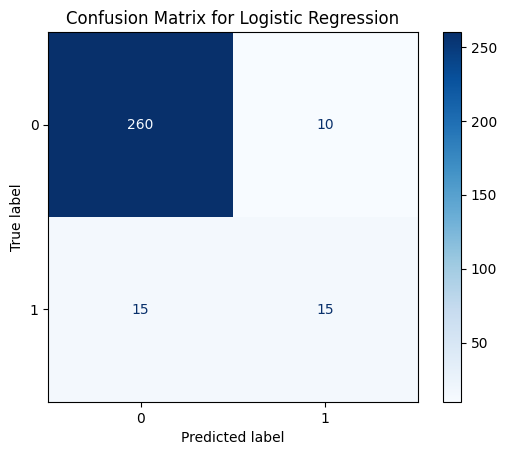

In [49]:

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_log_reg)

# Display it with labels and color
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()


### Experiment 2: Train Random Forest Classifier

In [50]:
rf_clf = RandomForestClassifier(n_estimators=30, max_depth=3)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       270
           1       0.91      0.70      0.79        30

    accuracy                           0.96       300
   macro avg       0.94      0.85      0.89       300
weighted avg       0.96      0.96      0.96       300



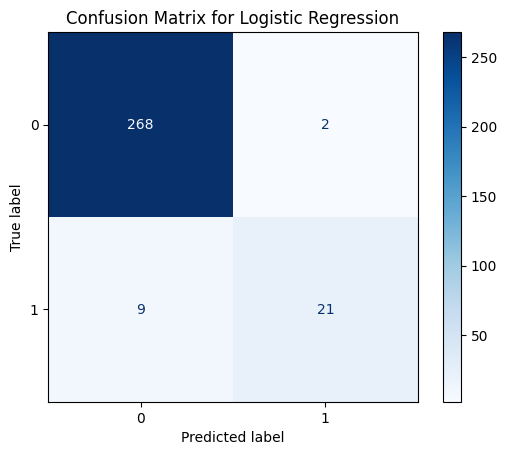

In [51]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Display it with labels and color
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

### Experiment 3: Train XGBoost

In [52]:
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       270
           1       0.96      0.80      0.87        30

    accuracy                           0.98       300
   macro avg       0.97      0.90      0.93       300
weighted avg       0.98      0.98      0.98       300



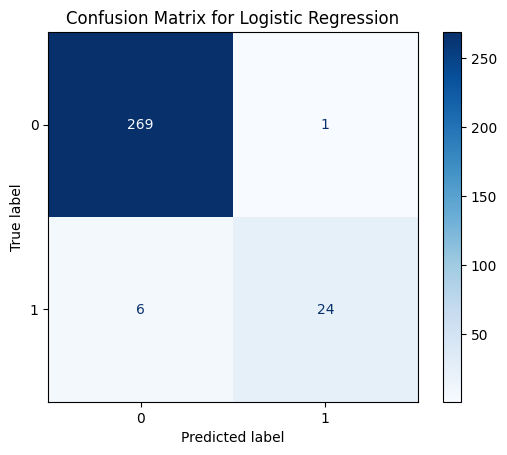

In [53]:
cm = confusion_matrix(y_test, y_pred_xgb)

# Display it with labels and color
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

### Experiment 4: Handle class imbalance using SMOTETomek and then Train XGBoost

In [54]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

np.unique(y_train_res, return_counts=True)

(array([0, 1]), array([619, 619]))

In [55]:
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train_res, y_train_res)
y_pred_xgb = xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       270
           1       0.81      0.83      0.82        30

    accuracy                           0.96       300
   macro avg       0.89      0.91      0.90       300
weighted avg       0.96      0.96      0.96       300



<h2 align="center" style="color:White">Track Experiments Using MLFlow</h2>

In [56]:
models = [
    (
        "Logistic Regression", 
        {"C": 1, "solver": 'liblinear'},
        LogisticRegression(), 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "Random Forest", 
        {"n_estimators": 30, "max_depth": 3},
        RandomForestClassifier(), 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "XGBClassifier",
        {"use_label_encoder": False, "eval_metric": 'logloss'},
        XGBClassifier(), 
        (X_train, y_train),
        (X_test, y_test)
    ),
    (
        "XGBClassifier With SMOTE",
        {"use_label_encoder": False, "eval_metric": 'logloss'},
        XGBClassifier(), 
        (X_train_res, y_train_res),
        (X_test, y_test)
    )
]

In [57]:
reports = []

for model_name, model, train_set, test_set in models:
    X_train = train_set[0]
    y_train = train_set[1]
    X_test = test_set[0]
    y_test = test_set[1]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    reports.append(report)

ValueError: too many values to unpack (expected 4)

In [ ]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

In [ ]:
# Initialize MLflow
mlflow.set_experiment("Anomaly Detection")
mlflow.set_tracking_uri("http://127.0.0.1:5000")

for i, element in enumerate(models):
    model_name = element[0]
    model = element[1]
    report = reports[i]
    
    with mlflow.start_run(run_name=model_name):        
        mlflow.log_param("model", model_name)
        mlflow.log_metric('accuracy', report['accuracy'])
        mlflow.log_metric('recall_class_1', report['1']['recall'])
        mlflow.log_metric('recall_class_0', report['0']['recall'])
        mlflow.log_metric('f1_score_macro', report['macro avg']['f1-score'])        
        
        if "XGB" in model_name:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")  

2025/04/23 13:59:15 INFO mlflow.tracking.fluent: Experiment with name 'Anomaly Detection' does not exist. Creating a new experiment.
2025/04/23 13:59:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Logistic Regression at: http://127.0.0.1:5000/#/experiments/556564752184052685/runs/640c5905bef0448fb86fbbdeecfe41a0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/556564752184052685


2025/04/23 13:59:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/556564752184052685/runs/9ec57c674b5d48deb1e891a37a8856f7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/556564752184052685


2025/04/23 13:59:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run XGBClassifier at: http://127.0.0.1:5000/#/experiments/556564752184052685/runs/9544a998ba9f4e0286b24c8d162b311f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/556564752184052685


2025/04/23 13:59:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run XGBClassifier With SMOTE at: http://127.0.0.1:5000/#/experiments/556564752184052685/runs/3d7c3cb3bc17450cab52e6a8a3679d4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/556564752184052685


### Register the Model

In [ ]:
model_name = 'XGB-Smote'
run_id=input('Please type RunID')
model_uri = f'runs:/{run_id}/model'

with mlflow.start_run(run_id=run_id):
    mlflow.register_model(model_uri=model_uri, name=model_name)

Successfully registered model 'XGB-Smote'.
2025/04/23 14:19:56 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGB-Smote, version 1


🏃 View run XGBClassifier With SMOTE at: http://127.0.0.1:5000/#/experiments/556564752184052685/runs/3d7c3cb3bc17450cab52e6a8a3679d4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/556564752184052685


Created version '1' of model 'XGB-Smote'.


### Load The Model

In [ ]:
model_version = 1
model_uri = f"models:/{model_name}/{model_version}"
print(model_uri)

loaded_model = mlflow.xgboost.load_model(model_uri)
y_pred = loaded_model.predict(X_test)
y_pred[:4]

models:/XGB-Smote/1


array([0, 0, 0, 0])

### Transition the Model to Production

In [ ]:
current_model_uri = f"models:/{model_name}@challenger"
production_model_name = "anomaly-detection-prod"

client = mlflow.MlflowClient()
client.copy_model_version(src_model_uri=current_model_uri, dst_name=production_model_name)

Registered model 'anomaly-detection-prod' already exists. Creating a new version of this model...
Copied version '1' of model 'XGB-Smote' to version '2' of model 'anomaly-detection-prod'.


<ModelVersion: aliases=[], creation_timestamp=1745407153340, current_stage='None', description='', last_updated_timestamp=1745407153340, name='anomaly-detection-prod', run_id='3d7c3cb3bc17450cab52e6a8a3679d4c', run_link='', source='models:/XGB-Smote/1', status='READY', status_message=None, tags={}, user_id='', version='2'>

In [ ]:
model_version = 1
prod_model_uri = f"models:/{production_model_name}@champion"

loaded_model = mlflow.xgboost.load_model(prod_model_uri)
y_pred = loaded_model.predict(X_test)
y_pred[:4]

array([0, 0, 0, 0])

In [ ]:
prod_model_uri

'models:/anomaly-detection-prod@champion'

In [ ]:
#mlflow models serve -m "models:/anomaly-detection-prod@champion" --no-conda -p 5000
